
# Задачі кластеризації та класифікації


<h2>Мета</h2>

Ознайомитись з різновидами моделей для задач кластеризації та класифікації, а також методами побудови та оцінки цих моделей. Після завершення цієї лабораторної роботи ви зможете:

* Використовувати прості моделі для задач кластеризації та класифікації
* Використовувати перехресну перевірку для оцінки якості моделі
* Обирати оптимальну складність моделі для уникнення перенавчання
* Вдосконалювати моделі за допомогою підбору параметрів


<div class="alert alert-danger alertdanger" style="margin-top: 20px">

# <h1 id="task">Завдання, що оцінюються </h1>

</div>


1. Скачайте дані із файлу <a href="https://drive.google.com/file/d/1wSj5SKRPKOjNPP2cyqaNpxRCinKEmJkO/view?usp=drive_link" target="_blank">'clean_data2.csv'</a> (Data2.csv з виправленими помилками та заповненими пропусками). Виконайте кластеризацію по ВВП на душу населення та щільності населення.
2. Використайте метод ліктя для підбору оптимальної кількості кластерів.
3. Визначіть, який регіон домінує в кожному з кластерів.
4. Побудуйте кілька (3-5) моделей класифікації, що визначають регіон, до якого належить країна, по ознаках 'GDP per capita', 'Population', 'CO2 emission', 'Area'. Оцініть точність класифікації (використайте 20% загального набору в якості тестових даних).
5. Для однієї з моделей виконайте підбір параметра. Обгрунтуйте ваш вибір.

<a name="task1"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task1">Завдання  #1: </h2>

<p>Виконайте кластеризацію по ВВП на душу населення та щільності населення. </p>
</div>


Зчитую дані з файлу у датафрейм


In [1]:
import pandas as pd

DATA_PATH = 'data/clean_data.csv'

df = pd.read_csv(DATA_PATH, sep=';', encoding='cp1252')

df[['country_name', 'region']] =  df[['country_name', 'region']].astype('string')
df.dtypes


country_name          string[python]
region                string[python]
gdp_per_capita                 int64
population                     int64
co2_emission                 float64
area                         float64
population_density           float64
dtype: object

Виділяю параметри для кластеризації

In [2]:
features = df[['gdp_per_capita', 'population_density']]

features

,gdp_per_capita,population_density
0,5617787463,53.083405
1,412498239,100.038296
2,3916881571,17.048902
3,3698862203,164.427660
4,3308700233,23.111786
...,...,...
200,3675459700,34.612334
201,2170648054,280.091671
202,990334774,52.245796
203,1269573537,22.045136


Будую модель методом k середніх з кількістю кластерів 8

In [3]:
from sklearn.cluster import KMeans


kmeans = KMeans(
    init='random',
    n_clusters=8,
    n_init=10,
    max_iter=300,
)

kmeans.fit(features)

KMeans(init='random', n_init=10)

<p>Отримані центри кластерів:</p>


In [4]:
kmeans.cluster_centers_

array([[3.77994983e+09, 2.38399029e+02],
       [6.11159523e+09, 7.57408767e+01],
       [2.61678383e+09, 2.46789683e+02],
       [3.42287489e+08, 6.97688568e+01],
       [1.43620874e+09, 1.44864947e+02],
       [9.25839613e+09, 3.16936327e+02],
       [7.58173629e+09, 1.14668966e+03],
       [4.85909436e+09, 7.31103160e+02]])

<p>Масив із номерами кластерів для кожного рядка даних:</p>


In [5]:
kmeans.labels_

array([1, 3, 0, 0, 0, 4, 4, 0, 0, 7, 3, 0, 2, 2, 4, 4, 7, 0, 7, 6, 0, 2,
       2, 7, 6, 5, 0, 2, 6, 1, 2, 3, 4, 4, 3, 0, 0, 1, 4, 6, 1, 6, 0, 3,
       3, 4, 4, 0, 0, 2, 4, 7, 0, 6, 1, 1, 0, 0, 5, 0, 3, 6, 0, 7, 7, 0,
       0, 6, 7, 0, 0, 4, 0, 4, 0, 4, 0, 1, 1, 7, 6, 2, 7, 3, 1, 4, 0, 7,
       7, 1, 0, 2, 7, 0, 0, 6, 4, 4, 0, 2, 2, 4, 2, 4, 6, 4, 7, 0, 0, 3,
       4, 6, 3, 0, 2, 4, 5, 6, 2, 0, 4, 5, 6, 2, 4, 0, 6, 2, 0, 4, 7, 6,
       6, 7, 0, 0, 2, 0, 2, 3, 4, 4, 4, 4, 2, 0, 1, 2, 4, 4, 1, 5, 5, 6,
       0, 4, 4, 5, 7, 4, 7, 7, 0, 4, 2, 4, 7, 7, 0, 3, 0, 4, 5, 6, 2, 1,
       2, 7, 6, 0, 6, 3, 1, 4, 1, 0, 4, 0, 3, 1, 0, 2, 1, 2, 0, 0, 1, 4,
       2, 2, 0, 2, 4, 4, 4], dtype=int32)

<p>Візуалізую отримані кластери:</p>


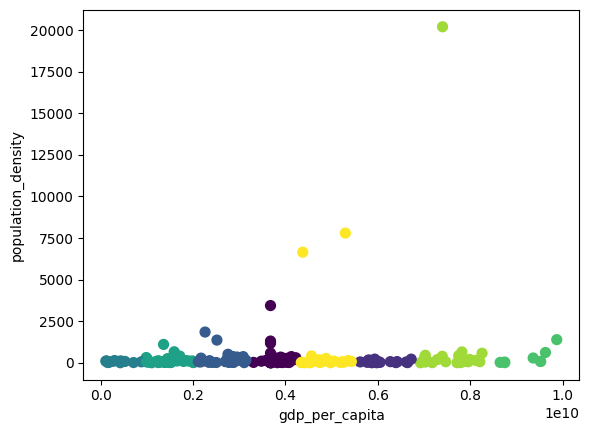

In [8]:
from matplotlib import pyplot as plt


plt.xlabel('gdp_per_capita')
plt.ylabel('population_density')

plt.scatter(features['gdp_per_capita'], features['population_density'], c=kmeans.labels_, s=50, cmap='viridis')

plt.show()


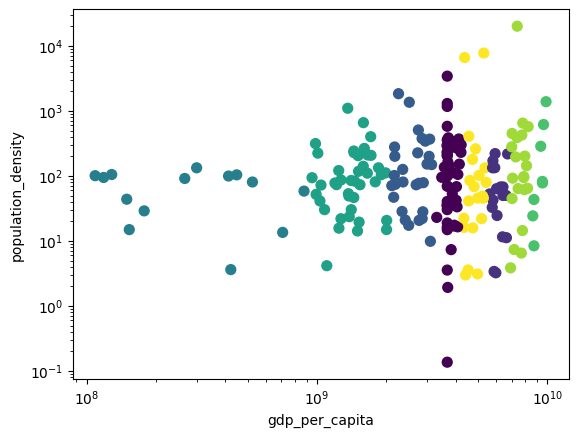

In [9]:



plt.xlabel('gdp_per_capita')
plt.ylabel('population_density')

plt.scatter(features['gdp_per_capita'], features['population_density'], c=kmeans.labels_, s=50, cmap='viridis')

plt.xscale('log')
plt.yscale('log')

plt.show()


<a name="task2"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task2">Завдання  #2: </h2>

<p>Використайте метод ліктя для підбору оптимальної кількості кластерів.</p>
</div>


Визначаю оптимальну кількість кластерів. Скористаюсь методом "ліктя". Для цього ініціалізую алгоритм k середніх кількістю кластерів від 1 до 10 і для кожної моделі рахую суму квадратів похибок (евклідових відстаней точок кластерів від відповідних центрів):

In [18]:
MAX_CLUSTERS = 10

params = {
    'init': 'random',
    'n_init': 10,
    'max_iter': 300,
    'random_state': 42,
}

inertia_values = []
cluster_range = range(1, MAX_CLUSTERS + 1)

for num_clusters in cluster_range:
    model = KMeans(n_clusters=num_clusters, **params)
    model.fit(features)
    inertia_values.append(model.inertia_)




<p>Візуалізую отримані результати:</p>


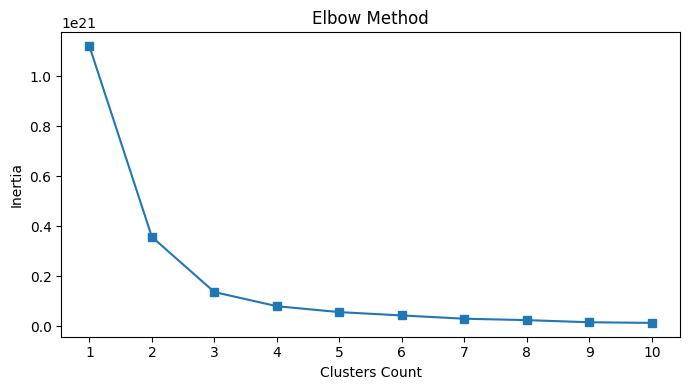

In [19]:
plt.figure(figsize=(7, 4))
plt.plot(list(cluster_range), inertia_values, linestyle='-', marker='s')
plt.xticks(list(cluster_range))
plt.xlabel('Clusters Count')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.tight_layout()
plt.show()

<p>Оптимальна кількість кластерів дорівнює 3-4
<p>Візуалізую для оптимальної кількості кластерів:</p>

In [24]:

from sklearn.metrics import silhouette_score


silhouette_scores = []
cluster_candidates = range(2, MAX_CLUSTERS + 1)


for clusters in cluster_candidates:
    model = KMeans(n_clusters=clusters, **params)
    model.fit(features)
    score = silhouette_score(features, model.labels_)
    silhouette_scores.append(score)

Візуалізую отримані результати

Text(0, 0.5, 'Silhouette Score')

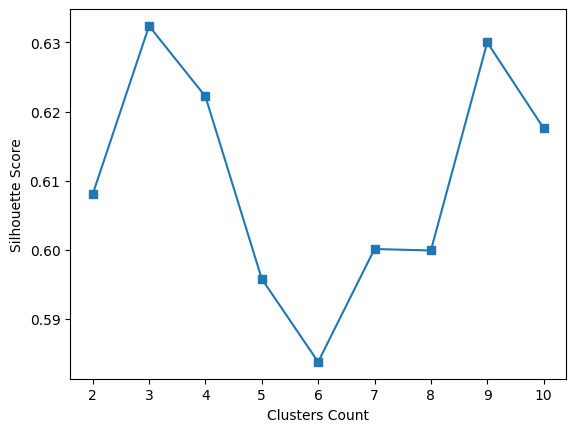

In [25]:
plt.plot(list(cluster_candidates), silhouette_scores, linestyle='-', marker='s')
plt.xticks(list(cluster_candidates))
plt.xlabel('Clusters Count')
plt.ylabel('Silhouette Score')


<a name="task3"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task3">Завдання  #3: </h2>

<p>Визначіть, який регіон домінує в кожному з кластерів.</p>
</div>


Додаю мітки кластерів в датафрейм

In [26]:
df['cluster'] = kmeans.labels_

Визначаю домінуючий регіон для кожного кластера

In [29]:
region_counts = df.groupby('cluster')['region'].value_counts()

region_counts

cluster  region                    
0        Europe & Central Asia         12
         Latin America & Caribbean     11
         East Asia & Pacific           10
         Middle East & North Africa     9
         Sub-Saharan Africa             8
         North America                  1
         South Asia                     1
1        Sub-Saharan Africa             6
         Latin America & Caribbean      5
         Europe & Central Asia          3
         East Asia & Pacific            1
         Middle East & North Africa     1
         North America                  1
         South Asia                     1
2        East Asia & Pacific            9
         Europe & Central Asia          5
         Sub-Saharan Africa             5
         Latin America & Caribbean      4
         Middle East & North Africa     4
         South Asia                     1
3        Europe & Central Asia          9
         Sub-Saharan Africa             3
         Latin America & Caribbean      

In [31]:
dominant_regions = region_counts.groupby(level=0).idxmax()

dominant_regions

cluster
0    (0, Europe & Central Asia)
1       (1, Sub-Saharan Africa)
2      (2, East Asia & Pacific)
3    (3, Europe & Central Asia)
4    (4, Europe & Central Asia)
5       (5, Sub-Saharan Africa)
6       (6, Sub-Saharan Africa)
7    (7, Europe & Central Asia)
Name: count, dtype: object

<a name="task4"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task4">Завдання  #4: </h2>

<p>Побудуйте кілька (3-5) моделей класифікації, що визначають регіон, до якого належить країна, по ознаках 'GDP per capita', 'Population', 'CO2 emission', 'Area'. Оцініть точність класифікації (використайте 20% загального набору в якості тестових даних).</p>
</div>


 Обираю потрібні ознаки:


In [35]:
all_features = pd.get_dummies(df[['gdp_per_capita', 'population', 'co2_emission', 'area']] )
all_features[['region']] = df[['region']]
all_features

,gdp_per_capita,population,co2_emission,area,region
0,5617787463,34656032,9809.225,652860.0,South Asia
1,412498239,2876101,5716.853,28750.0,Europe & Central Asia
2,3916881571,40606052,145400.217,2381740.0,Middle East & North Africa
3,3698862203,77281,462.042,470.0,Europe & Central Asia
4,3308700233,28813463,34763.160,1246700.0,Sub-Saharan Africa
...,...,...,...,...,...
200,3675459700,31568179,185220.170,912050.0,Latin America & Caribbean
201,2170648054,92701100,166910.839,330967.0,East Asia & Pacific
202,990334774,27584213,22698.730,527970.0,Middle East & North Africa
203,1269573537,16591390,4503.076,752610.0,Sub-Saharan Africa


 Розділяю датасет на навчальну і тестову вибірки за допомогою функції <code>train_test_split()</code>:


In [ ]:
from sklearn.model_selection import train_test_split


df_train, df_test = train_test_split(all_features, test_size=0.2, random_state=1)


print(df_train.count(), '\n')

print(df_test.count(), '\n')



gdp_per_capita    164
population        164
co2_emission      164
area              164
region            164
dtype: int64 

gdp_per_capita    41
population        41
co2_emission      41
area              41
region            41
dtype: int64 



<p>Розміщую цільові дані - Region -  в окремому датафреймі:</p>

In [47]:
x_train = df_train[['gdp_per_capita', 'population', 'co2_emission', 'area']]
y_train = df_train['region']

x_test = df_test[['gdp_per_capita', 'population', 'co2_emission', 'area']]
y_test = df_test['region']

<h3>Навчання та тестування моделей:</h3>

Для навчання були обрані наступні методи:

- Logistic Regression

- Decision Tree Classifier

- Random Forest Classifier

- Support Vector Machine (SVM)

- K-Nearest Neighbors (KNN)

In [50]:
from sklearn.discriminant_analysis import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier


models = {
    'Logistic Regression': LogisticRegression(max_iter=5000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Support Vector Machine': SVC(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier()
}

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

for name, model in models.items():
    if name in ['Logistic Regression', 'Support Vector Machine']:
        model.fit(x_train_scaled, y_train)
        y_pred = model.predict(x_test_scaled)
    else:
        model.fit(x_train, y_train)
        y_pred = model.predict(x_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    print(f'{name} Accuracy: {accuracy:.4f}')

Logistic Regression Accuracy: 0.2927
Decision Tree Accuracy: 0.4146
Random Forest Accuracy: 0.4146
Support Vector Machine Accuracy: 0.2683
K-Nearest Neighbors Accuracy: 0.1707


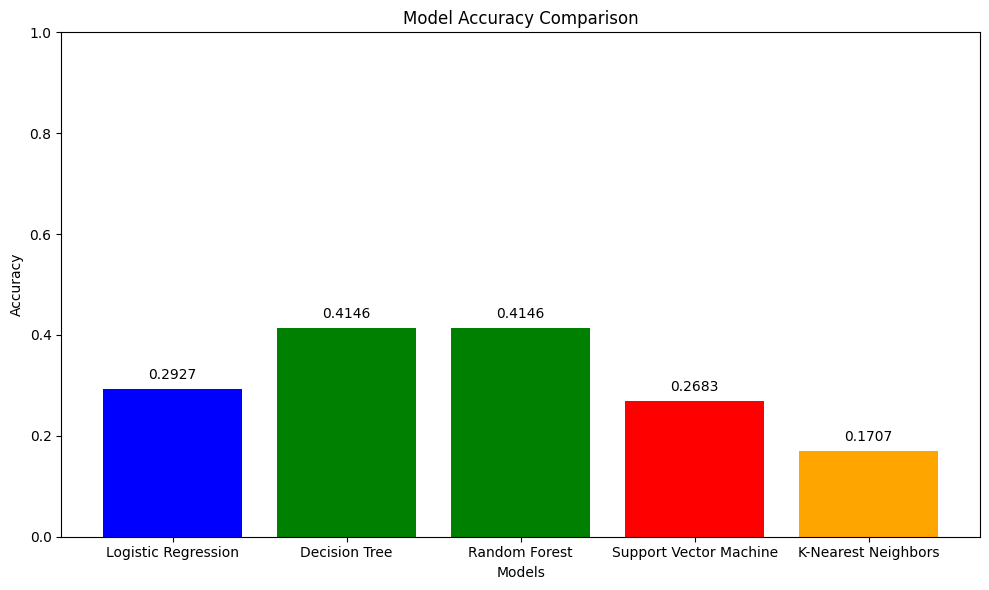

In [51]:
import matplotlib.pyplot as plt

# Accuracy results from the models
models_list = [
    'Logistic Regression', 'Decision Tree', 'Random Forest',
    'Support Vector Machine', 'K-Nearest Neighbors'
]
accuracy_list = [0.2927, 0.4146, 0.4146, 0.2683, 0.1707]

# Plotting the results
plt.figure(figsize=(10, 6))
plt.bar(models_list, accuracy_list, color=['blue', 'green', 'green', 'red', 'orange'])
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.ylim(0, 1)

# Adding the accuracy values on top of the bars
for i, accuracy in enumerate(accuracy_list):
    plt.text(i, accuracy + 0.02, f'{accuracy:.4f}', ha='center', fontsize=10)

# Show the plot
plt.tight_layout()
plt.show()


<h4>Висновок</h4>

Порівнюючи результати точності моделей, можна зробити висновок, що модель Decision Tree та модель Random Forest показали найкращий результат з точністю 0.4146, що виявляється вищим за інші моделі. Зокрема, моделі Logistic Regression та Support Vector Machine мали значно нижчі показники точності. Модель K-Nearest Neighbors показала найгірші результати.

<a name="task5"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task5">Завдання  #5: </h2>

<p>Для однієї з моделей виконайте підбір параметра. Обгрунтуйте ваш вибір.</p>
</div>


<p>Скористаюсь методом "ліктя" для визначення параметра max-depth методу decision tree </p>
<p>Для цього ініціалізую алгоритм з параметром від 1 до 30 і для кожної моделі порахую точність передбачення:</p>

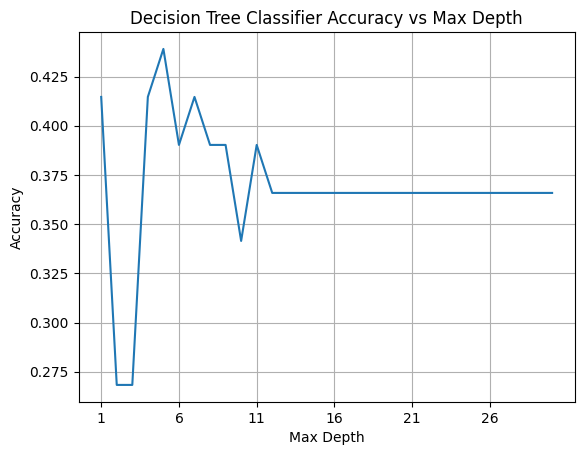

In [53]:
accuracy = []
MAX_KERNELS = 30

for i in range(1, MAX_KERNELS + 1):
    decision_tree = DecisionTreeClassifier(max_depth=i, random_state=1)
    decision_tree.fit(x_train, y_train)
    accuracy.append(decision_tree.score(x_test, y_test))
    

plt.plot(range(1, MAX_KERNELS + 1), accuracy)
plt.xticks(range(1, MAX_KERNELS + 1, 5))
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree Classifier Accuracy vs Max Depth')
plt.grid()
plt.show()

З графіка видно, що найкраще значення параметра max_depth знаходиться в межах від 5 до 7, тому що в цьому діапазоні досягається максимальна точність моделі (приблизно 0.44). Після цього точність або знижується, або стає стабільною на нижчому рівні.

<a name="task6"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task6"> Додаткове завдання: </h2>

<p>Використовуючи файл <a href="https://drive.google.com/file/d/1gxqzPQNlqrwrJI3zstMsvHQAbsdMPe-2/view?usp=drive_link" target="_blank">Data5.csv</a>:

1. Визначити кластер країн з найкращим розвитком (кластеризувати по Ie, Iec, Is; для k-середніх використати 4 кластера). Побудувати центри кластерів.
2. Провести кластеризацію по Сql, порахувати скільки країн потрапило в різні кластери, якщо порівнювати з п1.</p>
</div>


Згідно з методологією вимірювання сталого розвитку країн, сталий розвиток оцінюється за допомогою відповідного індексу у просторі трьох вимірів: економічного (Іес), екологічного (Іе) і соціально-інституціонального (Is). Цей індекс є вектором, норма якого визначає рівень сталого розвитку, а його просторове положення в системі координат (Iec,Ie,Is) характеризує міру «гармонійності» цього розвитку.

<details><summary>Натисніть тут, щоб побачити підказку до першого завдання</summary>

```python
# Зчитуємо заданий набір даних, зразу коригуючи
df = pd.read_csv(
    'Data5.csv', encoding='windows-1251', sep=';', decimal=','
).rename(columns={'Unnamed: 0': 'Country'})

df

```

</details>



In [ ]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання


<details><summary>Натисніть тут, щоб побачити підказку до другого завдання</summary>

Номери кластерів для першого і другого методів кластеризації зовсім не обовязково співпадатимуть. Щоб знайти відповідність, подивіться в які кластери з другого методу потрапляють центри кластерів з першого.

Порахувати скільки країн потрапило в різні кластери можна з використанням матриці невідповідностей (як аргументи поставти номери кластерів для першого і другого методів кластеризації).

</details>

In [ ]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання

<h2>Виконав студент групи ІП-33 <br> Соколов Олександр</h2>
